# Point-Cloud Dataset Transformation Schema

A slide-ready figure showing every step of the `PointCloudDataset` pipeline
(`eb_jepa/datasets/pointcloud/dataset.py`), from the raw `.off` mesh to the two
augmented SSL views `v1`, `v2`. Rendered with **pyvista** and exported to JPEG.


In [57]:
import numpy as np
import pyvista as pv
import matplotlib
from matplotlib_inline.backend_inline import flush_figures  # noqa: F401

matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from pathlib import Path

pv.set_plot_theme("document")
# (no global_axes in pyvista 0.48)

# Resolve relative to this notebook so it works from any kernel CWD
HERE = Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd()
if not (HERE / "chair_0080.off").exists():
    HERE = Path.cwd() / "notebooks"
OFF_PATH = HERE / "chair_0080.off"
PLY_PATH = HERE / "chair_0080.ply"
OUT_JPEG = HERE / "pointcloud_pipeline_schema.jpg"
print("HERE =", HERE)


HERE = c:\Users\SSI63\Documents\HtW\resources\eb_jepa\notebooks


## Step 0 — Load the raw `.off` mesh

The source asset is an OFF mesh (vertices + faces). We read only the vertices to
get a dense point cloud (~4901 points).


In [58]:
def read_off(path):
    """Read an OFF file, returning (vertices, faces).

    Faces are returned as a flat array in VTK format:
    [n, v0, v1, ..., vn, n, v0, v1, ...]
    so they can be passed directly to pv.PolyData(vertices, faces).
    """
    with open(path, "r") as f:
        first = f.readline().strip()
        if first == "OFF":
            header = f.readline().strip().split()
        else:
            header = first.split()
        n_v, n_f, _ = (
            int(header[0]),
            int(header[1]),
            int(header[2]) if len(header) > 2 else 0,
        )
        verts = np.array(
            [list(map(float, f.readline().split()[:3])) for _ in range(n_v)]
        )
        faces_flat = []
        for _ in range(n_f):
            parts = list(map(int, f.readline().split()))
            n = parts[0]
            faces_flat.append(n)
            faces_flat.extend(parts[1 : 1 + n])
    return verts, np.array(faces_flat)


pc_raw, pc_raw_faces = read_off(OFF_PATH)
print(f"OFF raw mesh: {pc_raw.shape[0]} vertices, {pc_raw_faces.size // 4} faces")


OFF raw mesh: 4901 vertices, 7586 faces


## Step 1 — Convert OFF → PLY (2048 points, unit-sphere normalized)

The ModelNet40 HDF5 release stores each shape as a 2048-point PLY, already
centered and normalized to the unit sphere. We reuse the provided
`chair_0080.ply`.


In [59]:
def read_ply_ascii(path):
    with open(path, "r") as f:
        line = f.readline().strip()
        assert line == "ply"
        n_v = 0
        while True:
            line = f.readline().strip()
            if line.startswith("element vertex"):
                n_v = int(line.split()[-1])
            if line == "end_header":
                break
        verts = np.array(
            [list(map(float, f.readline().split()[:3])) for _ in range(n_v)]
        )
    return verts


pc_ply = read_ply_ascii(PLY_PATH)
print(f"PLY normalized: {pc_ply.shape[0]} points")


PLY normalized: 2048 points


## Step 2 — Reproduce `PointCloudDataset._augment`

Each SSL view applies, in order: **subsample → rotate → scale → jitter →
normalize**. We split these into intermediate stages so each can be rendered.


In [60]:
def _rand_rot_so3(rng):
    u1, u2, u3 = rng.uniform(size=3)
    q = np.array(
        [
            np.sqrt(1 - u1) * np.sin(2 * np.pi * u2),
            np.sqrt(1 - u1) * np.cos(2 * np.pi * u2),
            np.sqrt(u1) * np.sin(2 * np.pi * u3),
            np.sqrt(u1) * np.cos(2 * np.pi * u3),
        ],
        dtype=np.float64,
    )
    w, x, y, z = q
    return np.array(
        [
            [1 - 2 * (y * y + z * z), 2 * (x * y - w * z), 2 * (x * z + w * y)],
            [2 * (x * y + w * z), 1 - 2 * (x * x + z * z), 2 * (y * z - w * x)],
            [2 * (x * z - w * y), 2 * (y * z + w * x), 1 - 2 * (x * x + y * y)],
        ],
        dtype=np.float32,
    )


def _normalize(pc):
    pc = pc - pc.mean(0, keepdims=True)
    scale = np.max(np.linalg.norm(pc, axis=1)) + 1e-6
    return pc / scale


rng = np.random.default_rng(42)
# stage A: subsample 1024 from 2048
idx = rng.choice(pc_ply.shape[0], 1024, replace=False)
pc_sub = pc_ply[idx]
# stage B: SO(3) rotation
R = _rand_rot_so3(rng)
pc_rot = (pc_sub @ R.T).astype(np.float32)
# stage C: random scale
s = rng.uniform(0.8, 1.25)
pc_scaled = (pc_rot * s).astype(np.float32)
# stage D: jitter
pc_jit = pc_scaled + rng.normal(0, 0.01, size=pc_scaled.shape).astype(np.float32)
# stage E: unit-sphere normalize
pc_norm = _normalize(pc_jit).astype(np.float32)

# second independent view (different rng draw)
rng2 = np.random.default_rng(7)
idx2 = rng2.choice(pc_ply.shape[0], 1024, replace=False)
v2 = _normalize(
    (
        _normalize(pc_ply[idx2] @ _rand_rot_so3(rng2).T) * rng2.uniform(0.8, 1.25)
        + rng2.normal(0, 0.01, size=(1024, 3)).astype(np.float32)
    )
).astype(np.float32)
v1 = pc_norm
print("v1", v1.shape, "v2", v2.shape)


v1 (1024, 3) v2 (1024, 3)


## Step 3 — Build the schema figure (single scene with arrows)

All 8 stages are placed in one 3D scene in an S-shaped layout (top row L→R,
bottom row R→L). Each point cloud is **colored by height** (z-elevation) with a
viridis colormap for depth perception. Large **`pv.Arrow`** objects connect
consecutive stages. **Eye-Dome Lighting** provides shading. Fonts are sized for
slide projection.


In [65]:
stages = [
    ("0. OFF Mesh\n(raw, %d pts)" % pc_raw.shape[0], pc_raw),
    ("1. PLY Convert\n(2048 pts, normalized)", pc_ply),
    ("2. Subsample\n(1024 pts)", pc_sub),
    ("3. Rotate SO(3)", pc_rot),
    ("4. Scale \u00d7%.2f" % s, pc_scaled),
    ("5. Jitter \u03c3=0.01", pc_jit),
    ("6. Normalize\n(unit sphere)", pc_norm),
]

# S-shaped grid layout: 4 cols x 2 rows (7 stages)
COL_SPACING = 3.8
ROW_SPACING = 3.8
CENTERS = []
for i in range(7):
    row, col = divmod(i, 4)
    if row == 1:
        col = 3 - col
    cx = (col - 1.5) * COL_SPACING
    cy = (0.5 - row) * ROW_SPACING
    CENTERS.append(np.array([cx, cy, 0.0], dtype=np.float64))

PC_SCALE = 0.85
POINT_SIZE = 14
TITLE_FONT = 50
MAIN_TITLE_FONT = 42

plotter = pv.Plotter(off_screen=True, window_size=(2560, 1440))
plotter.set_background("white")

# Main slide title
plotter.add_text(
    "Point-Cloud Dataset Transformation Pipeline",
    position=(0, 4.2, 0),
    font_size=MAIN_TITLE_FONT,
    color="#1a1a2e",
    font="arial",
)

for i, (title, pts) in enumerate(stages):
    center = CENTERS[i]

    # Normalize the raw OFF mesh so it has the same scale as other clouds
    pts_clean = pts.copy().astype(np.float64)
    pts_clean = pts_clean - pts_clean.mean(0, keepdims=True)
    max_norm = np.max(np.linalg.norm(pts_clean, axis=1)) + 1e-6
    pts_clean = pts_clean / max_norm

    if i == 0:
        # Stage 0: render as a proper surface mesh (not dots)
        mesh = pv.PolyData((pts_clean * PC_SCALE) + center, pc_raw_faces)
        mesh["height"] = mesh.points[:, 2]
        plotter.add_mesh(
            mesh,
            scalars="height",
            cmap="viridis",
            show_scalar_bar=False,
            smooth_shading=True,
        )
    else:
        # Color by z-height (elevation) for depth shading
        cloud = pv.PolyData((pts_clean * PC_SCALE) + center)
        cloud["height"] = cloud.points[:, 2]
        plotter.add_mesh(
            cloud,
            scalars="height",
            cmap="viridis",
            point_size=POINT_SIZE,
            render_points_as_spheres=True,
            show_scalar_bar=False,
        )

    # Stage 6 (Normalize): show the unit sphere the points are fitted to
    if i == 6:
        sph = pv.Sphere(radius=PC_SCALE, center=center)
        plotter.add_mesh(sph, color="gray", opacity=0.08, style="surface")
        plotter.add_mesh(
            sph, color="gray", style="wireframe", opacity=0.15, line_width=0.5
        )

# Arrows between consecutive stages
ARROW_COLOR = "#2c3e50"
for i in range(6):
    start = CENTERS[i].copy()
    end = CENTERS[i + 1].copy()
    direction = end - start
    length = np.linalg.norm(direction)
    direction_unit = direction / length
    gap = 1.05
    arrow_start = start + direction_unit * gap
    arrow_end = end - direction_unit * gap
    arrow_dir = arrow_end - arrow_start
    arrow_len = np.linalg.norm(arrow_dir)
    arrow = pv.Arrow(
        start=arrow_start,
        direction=arrow_dir,
        scale=arrow_len,
        shaft_radius=0.035,
        tip_radius=0.09,
        tip_length=0.25,
    )
    plotter.add_mesh(arrow, color=ARROW_COLOR)

# Stage labels — single call with all points/texts (pyvista handles arrays)
label_points = np.array([c + np.array([0.0, 1.6, 0.0]) for c in CENTERS])
label_texts = [t for t, _ in stages]
plotter.add_point_labels(
    label_points,
    label_texts,
    font_size=TITLE_FONT,
    text_color="#1a1a2e",
    font_family="arial",
    fill_shape=False,
    margin=0,
    shape_opacity=0,
    always_visible=True,
    justification_horizontal="center",
    justification_vertical="bottom",
)

# Camera: top-down at an angle
plotter.camera_position = [
    (0.0, -2.0, 16.0),
    (0.0, 0.0, 0.0),
    (0.0, 0.0, 1.0),
]
plotter.camera.zoom(0.75)

plotter.screenshot(str(OUT_JPEG), scale=2)

print(f"Saved schema to {OUT_JPEG}")

Saved schema to c:\Users\SSI63\Documents\HtW\resources\eb_jepa\notebooks\pointcloud_pipeline_schema.jpg


## Step 4 — View the exported JPEG


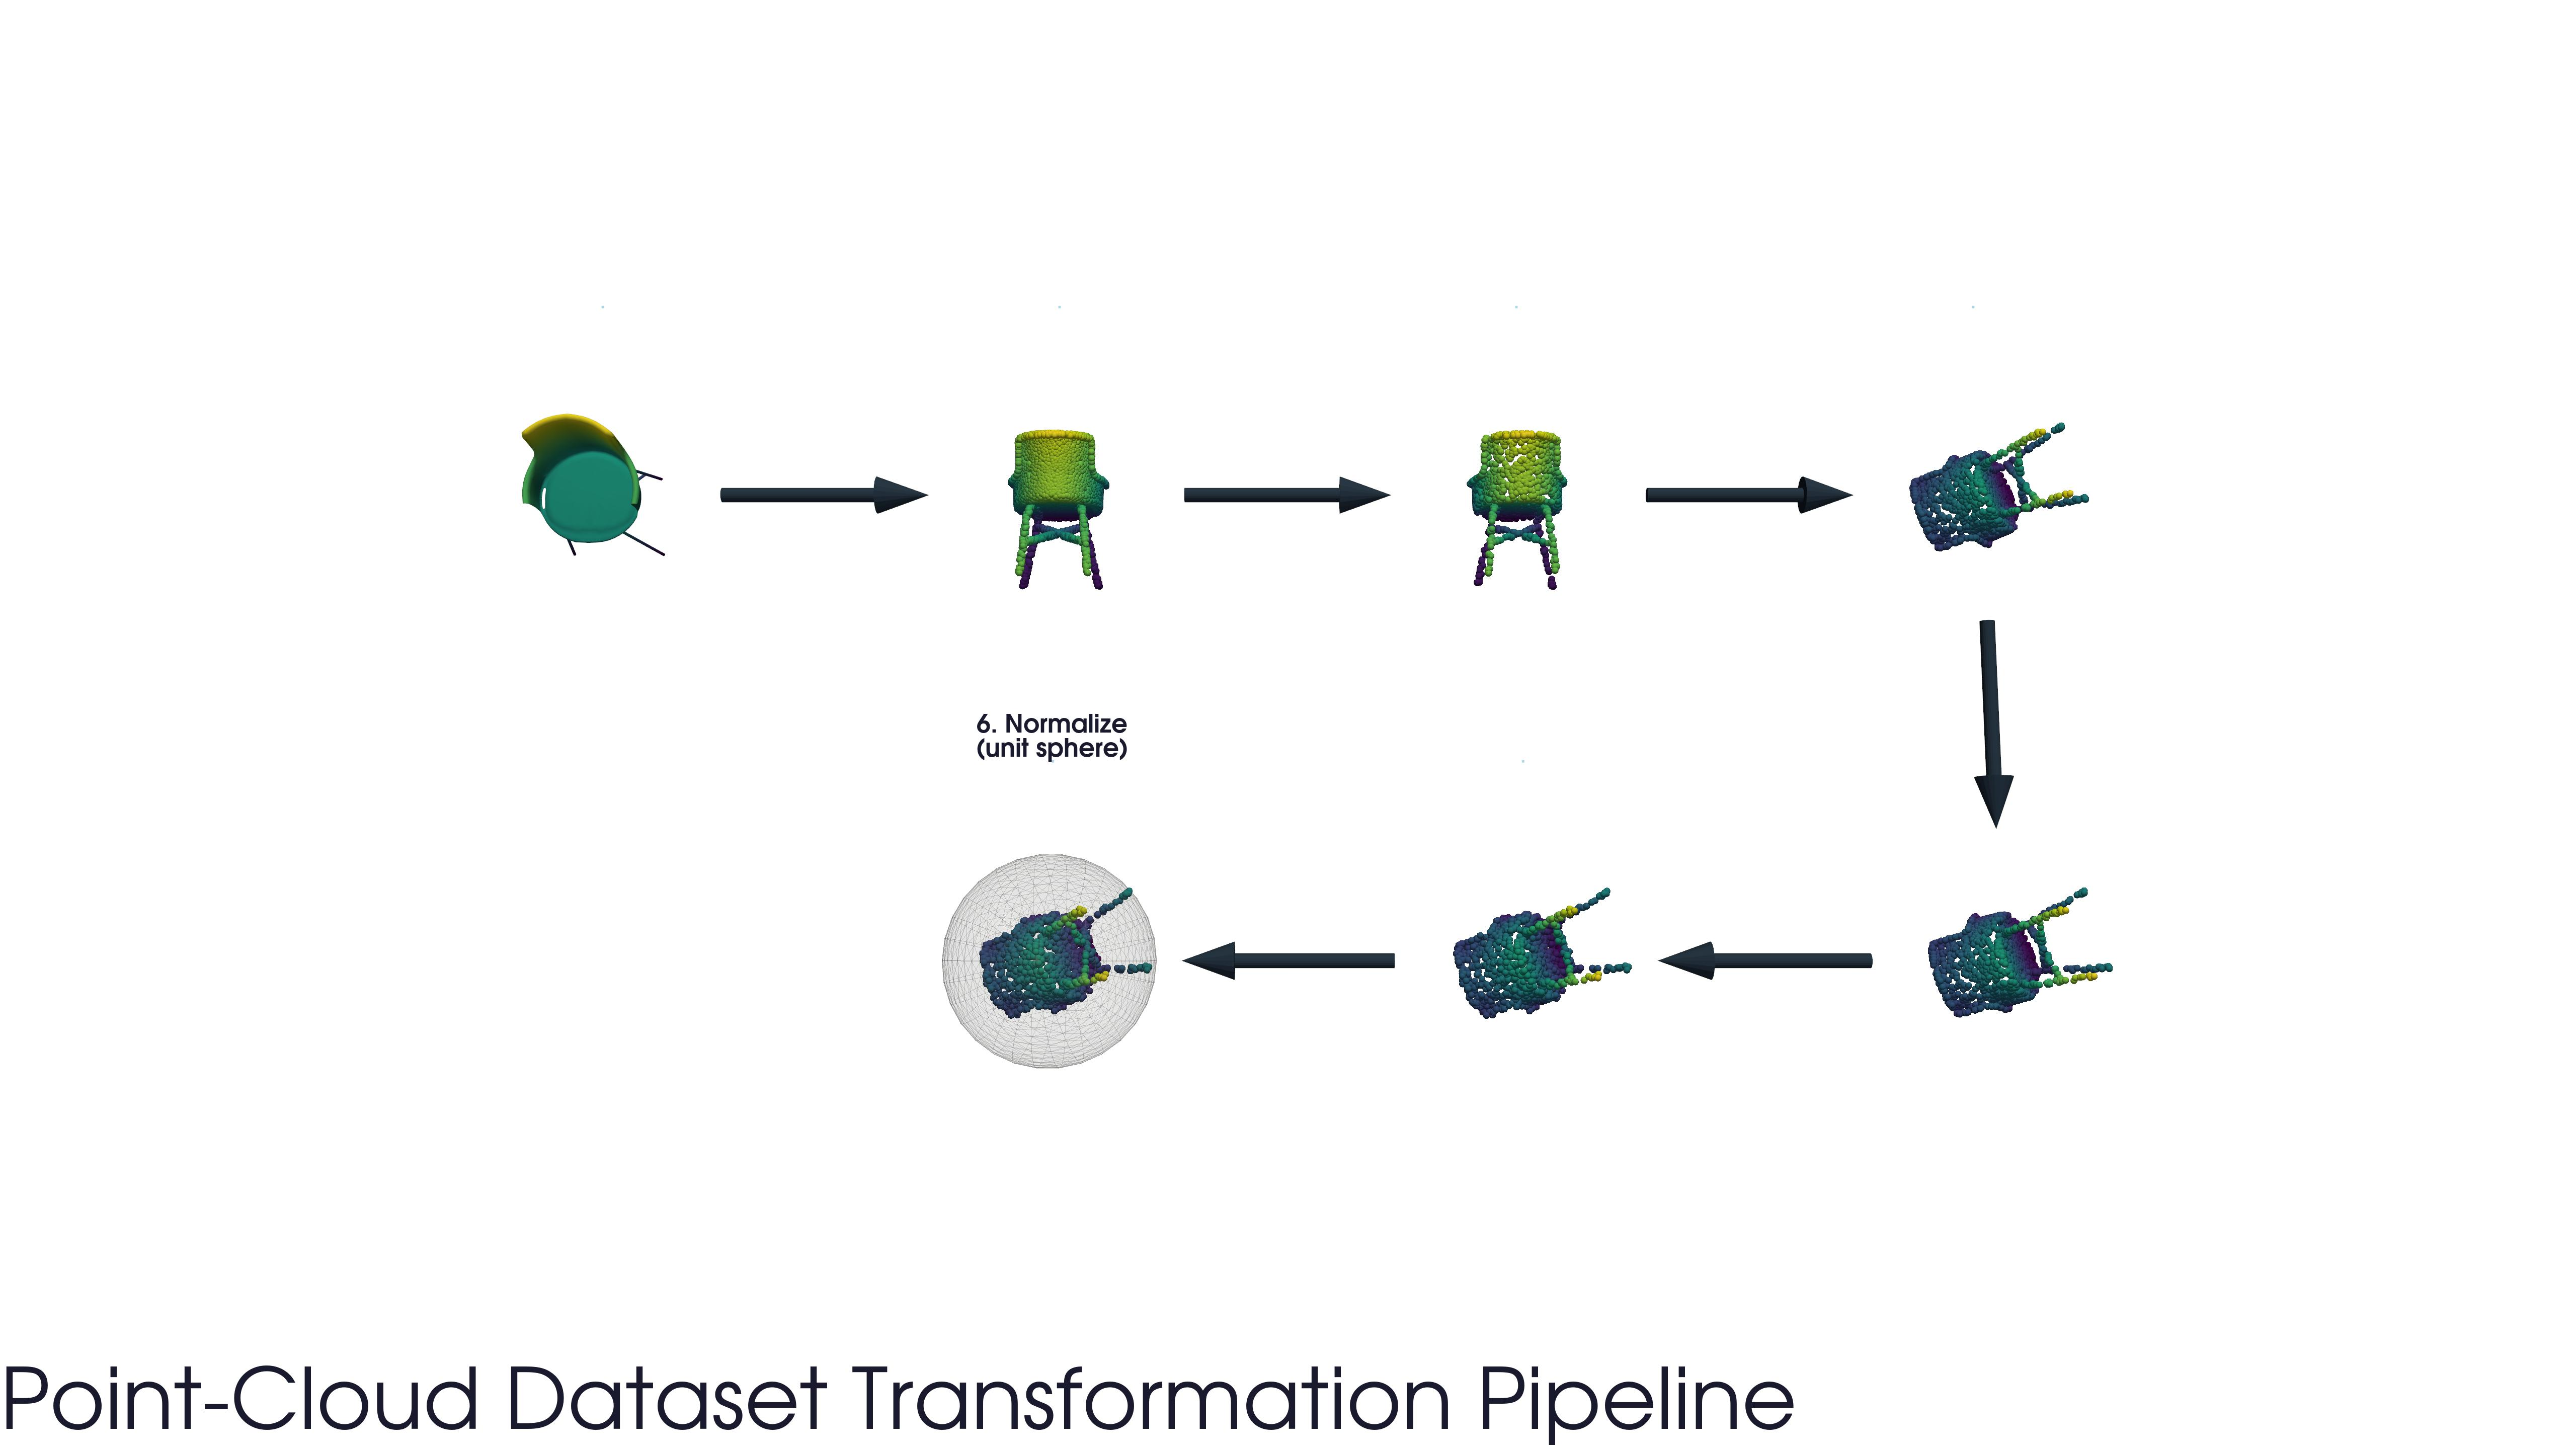

In [66]:
from IPython.display import Image, display

display(Image(filename=str(OUT_JPEG), width=1200))


## Single Chair Renders\n\nNon-rotated vs rotated `chair_0080.off`.


Saved to c:\Users\SSI63\Documents\HtW\resources\eb_jepa\notebooks\chair_augmentation_pipeline.jpg


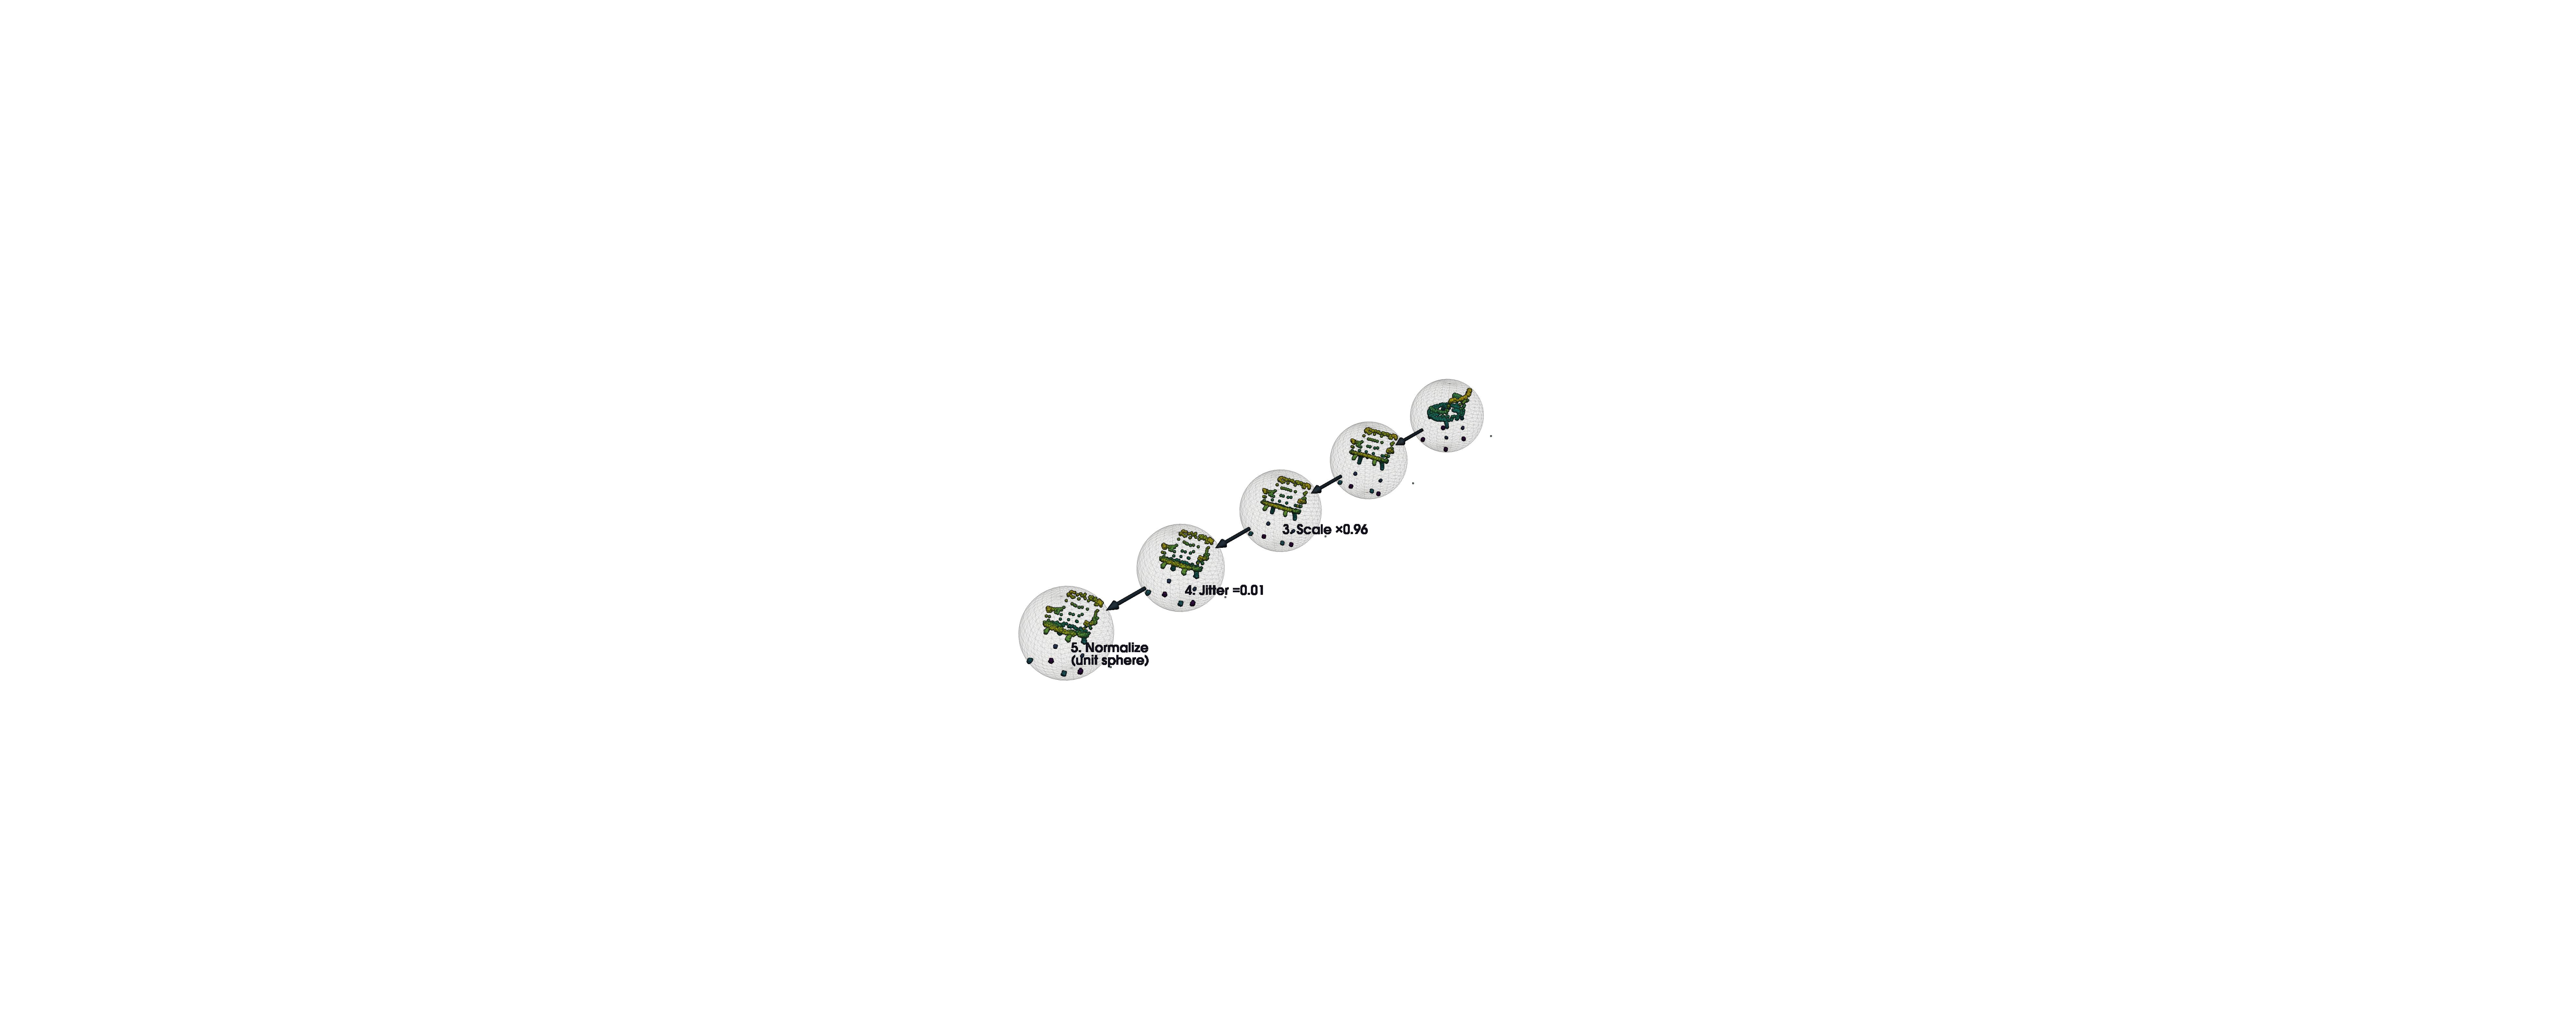

In [63]:
# Chair augmentation pipeline — each step of _augment() with titles
# Reproduces PointCloudDataset._augment from eb_jepa/datasets/pointcloud/dataset.py
chair_full = pc_raw.copy().astype(np.float64)
chair_full = chair_full - chair_full.mean(0, keepdims=True)
_max = np.max(np.linalg.norm(chair_full, axis=1)) + 1e-6
chair_full = chair_full / _max

# --- Reproduce _augment(pc, rng) step by step ---
_rng = np.random.default_rng(42)

# Step 1: Subsample 1024 points
_idx = _rng.choice(chair_full.shape[0], 1024, replace=False)
_aug_sub = chair_full[_idx]

# Step 2: SO(3) rotation
_aug_rot = (_aug_sub @ _rand_rot_so3(_rng).T).astype(np.float64)

# Step 3: Random scale
_aug_s = _rng.uniform(0.8, 1.25)
_aug_scaled = (_aug_rot * _aug_s).astype(np.float64)

# Step 4: Jitter
_aug_jit = (_aug_scaled + _rng.normal(0, 0.01, size=_aug_scaled.shape)).astype(
    np.float64
)

# Step 5: Unit-sphere normalize
_aug_norm = _normalize(_aug_jit).astype(np.float64)

# --- Layout: 5 stages in a row ---
stages_aug = [
    ("1. Subsample\n(1024 pts)", _aug_sub),
    ("2. Rotate SO(3)", _aug_rot),
    ("3. Scale \u00d7%.2f" % _aug_s, _aug_scaled),
    ("4. Jitter \u03c3=0.01", _aug_jit),
    ("5. Normalize\n(unit sphere)", _aug_norm),
]

COL_SP = 3.2
CENTERS_AUG = [
    np.array([(i - 2) * COL_SP, 0.0, 0.0], dtype=np.float64) for i in range(5)
]

pl = pv.Plotter(off_screen=True, window_size=(4000, 1600))
pl.set_background("white")

for i, (title, pts) in enumerate(stages_aug):
    center = CENTERS_AUG[i]

    # Translucent unit sphere
    sph = pv.Sphere(radius=1.0, center=center)
    pl.add_mesh(sph, color="gray", opacity=0.05, style="surface")
    pl.add_mesh(sph, color="gray", style="wireframe", opacity=0.10, line_width=0.5)

    # Point cloud
    cloud = pv.PolyData(pts + center)
    cloud["height"] = cloud.points[:, 2]
    pl.add_mesh(
        cloud,
        scalars="height",
        cmap="viridis",
        point_size=10,
        render_points_as_spheres=True,
        show_scalar_bar=False,
    )

# Arrows between consecutive stages
for i in range(4):
    start = CENTERS_AUG[i].copy()
    end = CENTERS_AUG[i + 1].copy()
    direction = end - start
    length = np.linalg.norm(direction)
    direction_unit = direction / length
    gap = 1.05
    arrow_start = start + direction_unit * gap
    arrow_end = end - direction_unit * gap
    arrow_dir = arrow_end - arrow_start
    arrow_len = np.linalg.norm(arrow_dir)
    aug_arrow = pv.Arrow(
        start=arrow_start,
        direction=arrow_dir,
        scale=arrow_len,
        shaft_radius=0.04,
        tip_radius=0.10,
        tip_length=0.25,
    )
    pl.add_mesh(aug_arrow, color="#2c3e50")

# Step titles above each chair
label_points = np.array([c + np.array([0.0, 1.5, 0.0]) for c in CENTERS_AUG])
label_texts = [t for t, _ in stages_aug]
pl.add_point_labels(
    label_points,
    label_texts,
    font_size=40,
    text_color="#1a1a2e",
    font_family="arial",
    fill_shape=False,
    margin=0,
    shape_opacity=0,
    always_visible=True,
    justification_horizontal="center",
    justification_vertical="bottom",
)

pl.enable_eye_dome_lighting()
pl.camera_position = "iso"
pl.camera.zoom(0.65)

OUT_CHAIR_AUG = HERE / "chair_augmentation_pipeline.jpg"
pl.screenshot(str(OUT_CHAIR_AUG), scale=2)
print(f"Saved to {OUT_CHAIR_AUG}")
display(Image(filename=str(OUT_CHAIR_AUG), width=1000))


## Pipeline summary (for the slide)

| Step | Operation   | Points | Notes                                           |
| ---- | ----------- | ------ | ----------------------------------------------- |
| 0    | `.off` mesh | ~4901  | raw ModelNet asset, unnormalized                |
| 1    | → `.ply`    | 2048   | center + unit-sphere normalize                  |
| 2    | Subsample   | 1024   | `rng.choice(N, 1024)`                           |
| 3    | Rotate      | 1024   | SO(3) uniform (quaternion) — `rotate=so3`       |
| 4    | Scale       | 1024   | `* Uniform(0.8, 1.25)`                          |
| 5    | Jitter      | 1024   | `+ Normal(0, 0.01)`                             |
| 6    | Normalize   | 1024   | re-center + unit-sphere                         |
| 7    | Two views   | 2×1024 | `v1`, `v2` of same object → VICReg / Point-JEPA |

Source: `eb_jepa/datasets/pointcloud/dataset.py` `PointCloudDataset._augment`.
